<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/russell-3000/download-10k-filings-russell-3000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download SEC 10-K Filings of Russell 3000 Companies

This ready-to-execute Python example demonstrates how to download all SEC 10-K filings for Russell 3000 companies from 2014 to 2023. The example can be easily adapted to download filings for other companies or different form types.

**Steps:**

1. Generate a list of tickers for all current Russell 3000 companies.
2. Use the [Query API](https://sec-api.io/docs/query-api) to retrieve the URLs of historical 10-K filings for each ticker.
3. Download all 10-K filings using the [Filing Download API](https://sec-api.io/docs/sec-filings-render-api).

### Create a List of Tickers for Russell 3000 Companies

The constituents of the Russell 3000 index can be found in the latest Form N-PORT filings for ETFs that mirror the index, or they can be directly downloaded as a CSV file from the corresponding ETF’s website.

For this example, the most up-to-date list of tickers is extracted from the CSV file available on the [iShares Russell 3000 ETF website](https://www.ishares.com/us/products/239714/ishares-russell-3000-etf). The CSV file includes the ticker, name, asset class, sector, and other details for each holding, and is downloaded and saved locally as `russell-3000-constituents.csv`.

The iShares website provides both historical and current constituent data:
- **Current constituents** can be accessed directly via the following link: [Download current constituents](https://www.ishares.com/us/products/239714/ishares-russell-3000-etf/1467271812596.ajax?fileType=csv&fileName=IWV_holdings&dataType=fund).

- **Historical constituents** for specific dates can be retrieved by appending a query parameter, such as:  
  `asOfDate=20221230`  
  Example URL: [Download historical constituents for 2022-12-30](https://www.ishares.com/us/products/239714/ishares-russell-3000-etf/1467271812596.ajax?fileType=csv&fileName=IWV_holdings&dataType=fund&asOfDate=20221230).

The CSV file with current constituents is used to generate the list of tickers for Russell 3000 companies, which will serve as input for the next step in the process.

In [ ]:
import requests

url = "https://www.ishares.com/us/products/239714/ishares-russell-3000-etf/1467271812596.ajax?" + \
      "fileType=csv&fileName=IWV_holdings&dataType=fund&asOfDate=20221230"

response = requests.get(url)

with open("russell-3000-constituents.csv", "wb") as f:
    f.write(response.content)

The CSV file begins with nine metadata lines and ends with a disclaimer, both of which need to be removed. The remaining rows contain the tickers, names, and other information of Russell 3000 companies. Using pandas, the CSV file can be read while skipping the first nine lines, and the last two lines can be removed by slicing the DataFrame.

In [ ]:
first_15_lines = "\n".join(response.text.split("\n")[:15])
print("First 15 lines of the CSV file:\n")
print(first_15_lines)

First 15 lines of the CSV file:

﻿iShares Russell 3000 ETF
Fund Holdings as of,"Dec 30, 2022"
Inception Date,"May 22, 2000"
Shares Outstanding,"49,100,000.00"
Stock,"-"
Bond,"-"
Cash,"-"
Other,"-"
 
Ticker,Name,Sector,Asset Class,Market Value,Weight (%),Notional Value,Shares,Price,Location,Exchange,Currency,FX Rate,Market Currency,Accrual Date
"AAPL","APPLE INC","Information Technology","Equity","559,365,151.11","5.16","559,365,151.11","4,305,127.00","129.93","United States","NASDAQ","USD","1.00","USD","-"
"MSFT","MICROSOFT CORP","Information Technology","Equity","513,917,712.42","4.74","513,917,712.42","2,142,931.00","239.82","United States","NASDAQ","USD","1.00","USD","-"
"AMZN","AMAZON COM INC","Consumer Discretionary","Equity","213,823,596.00","1.97","213,823,596.00","2,545,519.00","84.00","United States","NASDAQ","USD","1.00","USD","-"
"BRKB","BERKSHIRE HATHAWAY INC CLASS B","Financials","Equity","159,603,687.60","1.47","159,603,687.60","516,684.00","308.90","United States","New Y

In [ ]:
import pandas as pd

russell_3000 = pd.read_csv("russell-3000-constituents.csv", skiprows=9)
# remove last two rows
russell_3000 = russell_3000.iloc[:-2]

print("Number of all constituents:", len(russell_3000))
print("First five Russell 3000 constituents:")
russell_3000.head()

Number of all constituents: 2611
First five Russell 3000 constituents:


,Ticker,Name,Sector,Asset Class,Market Value,Weight (%),Notional Value,Shares,Price,Location,Exchange,Currency,FX Rate,Market Currency,Accrual Date
0,AAPL,APPLE INC,Information Technology,Equity,"559,365,151.11",5.16,"559,365,151.11","4,305,127.00",129.93,United States,NASDAQ,USD,1.0,USD,-
1,MSFT,MICROSOFT CORP,Information Technology,Equity,"513,917,712.42",4.74,"513,917,712.42","2,142,931.00",239.82,United States,NASDAQ,USD,1.0,USD,-
2,AMZN,AMAZON COM INC,Consumer Discretionary,Equity,"213,823,596.00",1.97,"213,823,596.00","2,545,519.00",84.00,United States,NASDAQ,USD,1.0,USD,-
3,BRKB,BERKSHIRE HATHAWAY INC CLASS B,Financials,Equity,"159,603,687.60",1.47,"159,603,687.60","516,684.00",308.90,United States,New York Stock Exchange Inc.,USD,1.0,USD,-
4,GOOGL,ALPHABET INC CLASS A,Communication,Equity,"151,996,026.75",1.40,"151,996,026.75","1,722,725.00",88.23,United States,NASDAQ,USD,1.0,USD,-


### Create a List of URLs for 10-K Filings

This part demonstrates how to use the [Query API](https://sec-api.io/docs/query-api) to retrieve the URLs of historical Form 10-K filings for all current Russell 3000 constituents and save them to local disk. Given the 2,611 constituents, a maximum of 2,611 Form 10-K filings per year can be expected, though likely fewer, as some holdings represent money market funds, futures, or other non-equity securities.

The Query API can return up to 10,000 results per search query, utilizing pagination. Since the search spans from 2014 to 2023 (a 10-year period), approximately 25,000 10-K filings are expected, based on an average of 2,500 Russell 3000 constituents disclosing 10-K filings per year. The initial search query might look like this:

```
formType:"10-K" AND filedAt:[2014-01-01 TO 2023-12-31] AND ticker:(<all tickers of Russell 3000 constituents>)
```

However, since the API can only return up to 10,000 results per query, the search must be broken into smaller chunks to ensure that each query retrieves fewer than 10,000 filings. One approach is to create individual search queries per company ticker, as each company typically files one 10-K per year, totaling around 10 filings over the 10-year period. A more efficient strategy would be to search for multiple companies (e.g., 100 tickers) at a time, which would yield around 1,000 10-K filings per query over 10 years.

Here’s an example of how to split the search queries:

```
# Query 1: First 100 constituents of the Russell 3000. Use pagination to retrieve all 1,000 10-K filings.
formType:"10-K" AND filedAt:[2014-01-01 TO 2023-12-31] AND ticker:(<first 100 tickers of Russell 3000 constituents>)

# Query 2: Next 100 constituents.
formType:"10-K" AND filedAt:[2014-01-01 TO 2023-12-31] AND ticker:(<next 100 tickers of Russell 3000 constituents>)

# Continue splitting the search by 100 tickers at a time...
```

As a first step, a simple function is defined to split up the list of 2,611 tickers into batches of 100. The function `create_batches` takes a list of tickers and a batch size as input and returns a list of batches, where each batch contains the specified number of tickers. The function is then used to create batches of 100 tickers each. For example, given a list `[A,B,C,D,E,F]` and a batch size of 3, the result would be two batches `[[A,B,C], [D,E,F]]`.

In [ ]:
def create_batches(tickers = [], batch_size = 100):
    return [list(tickers[i:i + batch_size]) for i in range(0, len(tickers), batch_size)]

ticker_batches = create_batches(russell_3000["Ticker"], batch_size=100)

# convert ticker_batches to dataframe with one column "Tickers"
# where each row contains a list (batch) of tickers
ticker_batches_df = pd.DataFrame({"Tickers": ticker_batches})

print("Number of batches:", len(ticker_batches_df))
print("First five ticker batches:")
ticker_batches_df.head()

Number of batches: 27
First five ticker batches:


,Tickers
0,"[AAPL, MSFT, AMZN, BRKB, GOOGL, UNH, GOOG, JNJ..."
1,"[SLB, REGN, VRTX, BDX, ZTS, TGT, APD, ITW, BSX..."
2,"[PH, PRU, MSCI, YUM, CHTR, ALL, ECL, KMI, LULU..."
3,"[VMC, AEE, ETR, WY, FE, FTV, EBAY, LEN, DTE, A..."
4,"[TXT, ETSY, MOS, HWM, WRB, AVY, SWKS, SYF, FIC..."


The next Python code snippet iterates over all batches, creating a search query for each batch to retrieve all 10-K filings for the respective tickers from 2014 to 2023. The filing URLs are then extracted from the Query API response and saved in a DataFrame. Since the Query API can handle up to 40 requests per second, the `pandarallel` package is used to parallelize requests and improve efficiency by performing multiple queries simultaneously.

`pandarallel` extends pandas DataFrame objects with the `.parallel_apply(func)` method, which applies a function in parallel across rows. The number of concurrent tasks is controlled by the `nb_workers` parameter, set via `pandarallel.initialize(nb_workers=4)`. Using `.parallel_apply`, the function to get all 10-K filing URLs is applied to each batch of tickers, enabling parallel processing of multiple batches, significantly speeding up the retrieval of metadata.

In [ ]:
pip install sec-api pandarallel ipywidgets

In [ ]:
from pandarallel import pandarallel
from sec_api import QueryApi

pandarallel.initialize(nb_workers=4, progress_bar=True)

SEC_API_KEY = "YOUR_API_KEY"

queryApi = QueryApi(api_key=SEC_API_KEY)

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [ ]:
def get_10K_filing_urls(row=None):
    if row is None:
        return []

    ticker_batch = row["Tickers"]

    if len(ticker_batch) == 0:
        return []

    # create a query string to search for 10-K filings for the given tickers
    # "(ticker:AAPL OR ticker:MSFT OR ...)"
    ticker_query = " OR ".join([f'ticker:"{ticker}"' for ticker in ticker_batch])
    ticker_query = f"({ticker_query})"
    # search for 10-K filings filed between 2014-01-01 and 2023-12-31
    date_query = "filedAt:[2014-01-01 TO 2023-12-31]"
    # exclude 10-K/A and NT 10-K filings
    form_type_query = 'formType:"10-K" AND NOT formType:"10-K/A" AND NOT formType:"NT"'

    search_query = f"{ticker_query} AND {date_query} AND {form_type_query}"

    search_params = {
        "query": search_query,
        "from": 0,
        "size": 50,
        "sort": [{"filedAt": {"order": "desc"}}],
    }

    print(f"Fetching filings for {ticker_batch[:4]}...\n")

    has_more_filings = True
    filing_urls = []

    while has_more_filings:

        search_results = queryApi.get_filings(search_params)
        filings = search_results["filings"]

        if len(filings) == 0:
            break

        # extract metadata for each filing
        # { "ticker": "...", "cik": "...", "filedAt": "...", "filingUrl": "..." }
        metadata = list(
            map(
                lambda f: {
                    "ticker": f["ticker"],
                    "cik": f["cik"],
                    "filedAt": f["filedAt"],
                    "accessionNo": f["accessionNo"],
                    "filingUrl": f["linkToFilingDetails"],
                },
                filings,
            )
        )

        filing_urls.extend(metadata)

        search_params["from"] += search_params["size"]

    return pd.DataFrame(filing_urls)


# use the first two batches of tickers for a test run
metadata = ticker_batches_df[:2].parallel_apply(get_10K_filing_urls, axis=1)
# uncomment the line below to process all batches
# metadata = ticker_batches_df.parallel_apply(get_10K_filing_urls, axis=1)

# concatenate the metadata dataframes to get a single dataframe
metadata = pd.concat(metadata.tolist(), ignore_index=True)

Fetching filings for ['SLB', 'REGN', 'VRTX', 'BDX']...
Fetching filings for ['AAPL', 'MSFT', 'AMZN', 'BRKB']...




In [ ]:
metadata.to_csv("russell-3000-10k-filing-urls.csv", index=False)
print("Filing metadata of 10-K filings disclosed between 2014 and 2023:")
metadata

Filing metadata of 10-K filings disclosed between 2014 and 2023:


,ticker,cik,filedAt,accessionNo,filingUrl
0,AMAT,6951,2023-12-15T16:01:24-05:00,0000006951-23-000041,https://www.sec.gov/Archives/edgar/data/6951/0...
1,DE,315189,2023-12-15T10:27:39-05:00,0001558370-23-019812,https://www.sec.gov/Archives/edgar/data/315189...
2,AVGO,1730168,2023-12-14T16:54:05-05:00,0001730168-23-000096,https://www.sec.gov/Archives/edgar/data/173016...
3,DIS,1744489,2023-11-21T17:04:04-05:00,0001744489-23-000216,https://www.sec.gov/Archives/edgar/data/174448...
4,ADI,6281,2023-11-21T16:24:08-05:00,0000006281-23-000203,https://www.sec.gov/Archives/edgar/data/6281/0...
...,...,...,...,...,...
1936,GD,40533,2014-02-07T09:05:33-05:00,0000040533-14-000002,https://www.sec.gov/Archives/edgar/data/40533/...
1937,BIIB,875045,2014-02-06T17:28:12-05:00,0000875045-14-000004,https://www.sec.gov/Archives/edgar/data/875045...
1938,GM,1467858,2014-02-06T12:49:42-05:00,0001467858-14-000043,https://www.sec.gov/Archives/edgar/data/146785...
1939,CMG,1058090,2014-02-04T20:22:21-05:00,0001193125-14-035451,https://www.sec.gov/Archives/edgar/data/105809...


### Download SEC 10-K Filings to Local Disk

After aggregating the URLs of all 10-K filings between 2014 and 2023 for companies in the Russell 3000 index, the `.get_filing(file_url)` method of the `RenderApi` class in the `sec-api` package is used to download the filings in their original HTML or text format. This method accepts the URL of the filing or any other EDGAR file (such as exhibits) and returns the original content.

For each company, the 10-K filings are downloaded and saved in a structured directory on the local disk. The directory structure is organized as follows: `filings/{ticker}/{filing_date}_{accession_number}.html`, where the filing content is stored as `.html` or `.txt` files. The filename includes the filing date and accession number for easy reference. An example of this structure is:

```
filings/
    AAPL/
        2022-10-31_0000320193-22-000002.html
        2021-10-29_0000320193-21-000096.html
        ...
    MSFT/
        2022-07-29_0001564590-22-031000.html
        2021-07-30_0001564590-21-034056.html
        ...
    ...
```

The `.get_filing(file_url)` function sends requests to the Filing Download API and supports up to 50 requests per second. To utilize this limit efficiently, the `pandarallel` package is used again to parallelize the downloading process. A new function `download_filing(row)` is defined to handle downloading and saving the filing content for each row in the `metadata` DataFrame. By applying this function to the DataFrame using `metadata.parallel_apply(download_filing)`, multiple filings are downloaded simultaneously, significantly speeding up the process.

In [ ]:
import os
from sec_api import RenderApi

renderApi = RenderApi(SEC_API_KEY)


def download_filing(row):
    ticker = row["ticker"]
    accessionNo = row["accessionNo"]
    filedAt = row["filedAt"].split("T")[0]
    filing_url = row["filingUrl"]

    try:
        content = renderApi.get_filing(filing_url)

        # check if path "filings/{ticker}/" exists. if not, create it
        if not os.path.exists(f"filings/{ticker}/"):
            os.makedirs(f"filings/{ticker}/")

        file_type = filing_url.split("/")[-1].split(".")[1]
        local_file_name = f"filings/{ticker}/{filedAt}_{accessionNo}.{file_type}"

        with open(local_file_name, "w") as f:
            f.write(content)

        print(f"✅ Downloaded {local_file_name}")
    except:
        print(f"❌ {ticker}: downloaded failed for {filing_url}")


# perform test download of first 10 filings
downloaded = metadata[:10].parallel_apply(download_filing, axis=1)
# uncomment the line below to download all filings
# downloaded = metadata.parallel_apply(download_filing, axis=1)

print(f"Completed downloading {len(downloaded)} filings")

✅ Downloaded filings/AMAT/2023-12-15_0000006951-23-000041.htm
✅ Downloaded filings/DIS/2023-11-21_0001744489-23-000216.htm
✅ Downloaded filings/DE/2023-12-15_0001558370-23-019812.htm
✅ Downloaded filings/ADI/2023-11-21_0000006281-23-000203.htm
✅ Downloaded filings/V/2023-11-15_0001403161-23-000099.htm
✅ Downloaded filings/QCOM/2023-11-01_0000804328-23-000055.htm
✅ Downloaded filings/AVGO/2023-12-14_0001730168-23-000096.htm
✅ Downloaded filings/SBUX/2023-11-17_0000829224-23-000058.htm
✅ Downloaded filings/AAPL/2023-11-02_0000320193-23-000106.htm
✅ Downloaded filings/ACN/2023-10-12_0001467373-23-000324.htm
Completed downloading 10 filings


Using a simple `for` loop to iterate over each filing's metadata would result in downloading all filings sequentially, due to Python's single-threaded architecture. This approach would take several hours to complete. By spreading the download tasks across four independent threads (or workers) with `pandarallel`, the total download time is reduced by approximately 75%, or to 1/4 of the original time. With five workers, the time would be reduced to 1/5 of the initial time.

Consider the following example:

- **Average time to download a single filing**: 300 ms
- **Number of filings to download**: 10 years × 2,500 filings per year = 25,000 filings

**Time calculation for downloading sequentially (1 filing at a time)**:
- Total time = (25,000 filings × 300 ms) / 1,000 ms (per second) / 60 seconds (per minute) = 125 minutes (or 2 hours)

**Time calculation for downloading with four workers (4 filings in parallel)**:
- Total time = (25,000 filings × 300 ms) / 1,000 ms / 60 seconds / 4 workers = 31 minutes (or 0.5 hours)

The figure below illustrates the difference between downloading 1 filing at a time versus downloading 4 filings in parallel. This parallel approach significantly reduces the overall download time and improves efficiency.

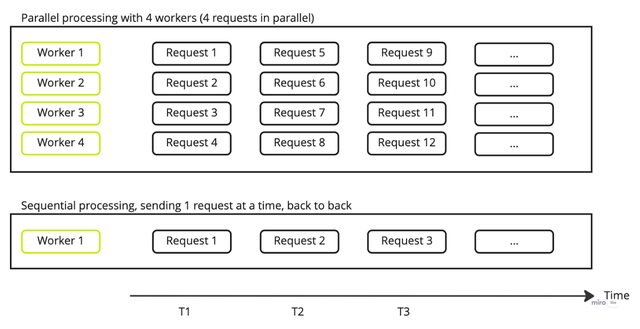